# Text Generation using RNN, LSTM, and GRU

Compare three sequence models on text generation.

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## Step 1: Load and Tokenize Corpus

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''

# Tokenize
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1

print(f"Vocabulary size: {total_words}")

Vocabulary size: 37


## Step 2: Create N-gram Sequences

In [3]:
input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (35, 7)
y shape: (35,)


## Step 3: Build Three Models

In [4]:
# RNN Model
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])
rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# LSTM Model
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# GRU Model
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])
gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Models built")

Models built


c:\Users\ayush\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


## Step 4: Train for 100 Epochs

In [5]:
rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
gru_history = gru_model.fit(X, y, epochs=100, verbose=0)

print("Training complete")

Training complete


## Step 5: Plot Training Loss

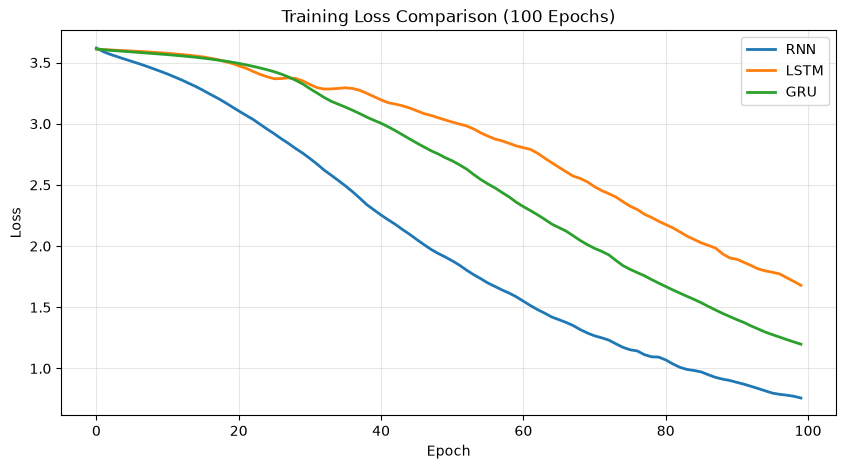

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_history.history['loss'], label='RNN', linewidth=2)
plt.plot(lstm_history.history['loss'], label='LSTM', linewidth=2)
plt.plot(gru_history.history['loss'], label='GRU', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison (100 Epochs)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 6: Text Generation Function

In [7]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## Step 7: Generate Text from All Models

In [8]:
print("RNN: ", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU: ", generate_text(gru_model, "deep learning", 5))

RNN:  deep learning models can generate meaningful sentences
LSTM: deep learning learning can artificial intelligence sentences
GRU:  deep learning models can generate meaningful sentences


## TASK 1: Custom Paragraph Corpus

In [9]:
custom_corpus = '''
machine learning algorithms learn from data
neural networks mimic biological brain structures
deep learning models process large amounts of data
artificial intelligence is transforming technology
supervised learning requires labeled training data
unsupervised learning discovers hidden patterns
'''

tokenizer_custom = Tokenizer()
tokenizer_custom.fit_on_texts([custom_corpus])
total_words_custom = len(tokenizer_custom.word_index) + 1

print(f"Custom corpus vocabulary size: {total_words_custom}")

Custom corpus vocabulary size: 32


## TASK 2: Increased Embedding Dimensions (32 → 64)

In [10]:
# Create sequences for custom corpus
input_sequences_custom = []
for line in custom_corpus.split('\n'):
    token_list = tokenizer_custom.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences_custom.append(n_gram_seq)

max_len_custom = max(len(seq) for seq in input_sequences_custom)
input_sequences_custom = pad_sequences(input_sequences_custom, maxlen=max_len_custom, padding='pre')

X_custom = input_sequences_custom[:, :-1]
y_custom = input_sequences_custom[:, -1]

# Model with 64-dim embeddings
model_task2 = Sequential([
    Embedding(total_words_custom, 64, input_length=max_len_custom-1),
    LSTM(64),
    Dense(total_words_custom, activation='softmax')
])
model_task2.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("Model with 64-dim embeddings created")

Model with 64-dim embeddings created


## TASK 3: Extended Training (100 → 200 Epochs)

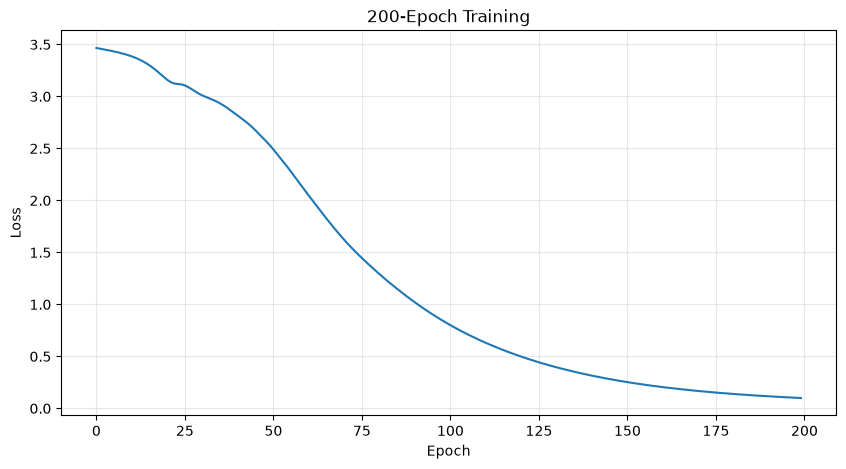

In [11]:
history_task3 = model_task2.fit(X_custom, y_custom, epochs=200, verbose=0)

plt.figure(figsize=(10, 5))
plt.plot(history_task3.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('200-Epoch Training')
plt.grid(True, alpha=0.3)
plt.show()

## TASK 4: Wider Hidden Layers (64 → 128)

In [12]:
model_task4 = Sequential([
    Embedding(total_words_custom, 64, input_length=max_len_custom-1),
    LSTM(128),
    Dense(total_words_custom, activation='softmax')
])
model_task4.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history_task4 = model_task4.fit(X_custom, y_custom, epochs=100, verbose=0)

print(f"Final loss: {history_task4.history['loss'][-1]:.4f}")

Final loss: 0.3351


## TASK 5: Generate 10 Words

In [13]:
def generate_text_10(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer_custom.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len_custom-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        
        output_word = ""
        for word, index in tokenizer_custom.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

print(generate_text_10(model_task4, "machine learning", 10))

machine learning algorithms learn from data data data data data data data
